# Analisis del Mercado Laboral en México (2020- 2024)
## Fuente: INEGI - Encuesta _Nacional de Ocupación y Empleo (ENOE)

Este proyecto analiza la evolución del desempleo, informalidad laboral y participación económica
en las 32 entidades federativas de México entre 2020 y 2024, utilizando datos oficiales del INEGI.

**Preguntas clave:**
- ¿Qué estados concentran mayor desempleo?
- ¿Cómo impactó el COVID-19 al mercado laboral?
- ¿Cuál es la brecha entre empleo formal e informal por región?

In [2]:
# importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8')
%matplotlib inline

print("✅ Librerias cargadas correctamente.")

✅ Librerias cargadas correctamente.


## Etapa 1: Carga y Exploración de Datos.

In [3]:
# Caragr datasets
estados = pd.read_csv('enoe_desempleo_mexico_2020_2024.csv')
registros = pd.read_csv('enoe_desempleo_largo_2020_2024.csv')

print(f"Dataset estados: {estados.shape}")
print(f"Dataset registros: {registros.shape}")
print("\nPrimeras filas:")
display(estados.head())

Dataset estados: (32, 24)
Dataset registros: (640, 8)

Primeras filas:


,entidad,td_2020_T1,td_2020_T2,td_2020_T3,td_2020_T4,td_2021_T1,td_2021_T2,td_2021_T3,td_2021_T4,td_2022_T1,...,td_2023_T2,td_2023_T3,td_2023_T4,td_2024_T1,td_2024_T2,td_2024_T3,td_2024_T4,informalidad_2024,participacion_2024,region
0,Aguascalientes,3.4,6.1,5.2,4.1,3.8,3.5,3.2,3.0,2.9,...,3.0,2.9,2.8,3.0,3.4,3.2,3.1,42.1,60.5,Centro-Norte
1,Baja California,3.5,5.8,4.9,4.0,3.7,3.4,3.1,2.9,2.8,...,2.7,2.6,2.5,2.7,2.9,2.8,2.7,38.5,62.3,Norte
2,Baja California Sur,2.8,4.2,3.6,3.1,2.9,2.7,2.5,2.3,2.2,...,2.1,2.0,1.9,2.1,2.2,2.1,2.0,35.2,67.0,Norte
3,Campeche,2.1,3.8,3.2,2.8,2.6,2.4,2.2,2.1,2.0,...,1.9,1.8,1.7,1.9,2.0,1.9,1.8,58.3,58.4,Sur-Sureste
4,Coahuila,3.8,6.2,5.3,4.5,4.2,3.9,3.6,3.4,3.3,...,3.3,3.2,3.1,3.3,3.7,3.5,3.5,35.8,62.8,Norte


In [6]:
print("=== Informacion del dataset ===")
print(f"\nEntidades: {estados['entidad'].nunique()}")
print(f"\nRegiones: {list(estados['region'].unique())}")
print("\nValores ausentes:")
print(estados.isnull().sum())
print("\nEstadisticas generales:")
display(registros['tasa_desocupacion'].describe().round(2))

=== Informacion del dataset ===

Entidades: 32

Regiones: ['Centro-Norte', 'Norte', 'Sur-Sureste', 'Occidente', 'Centro']

Valores ausentes:
entidad               0
td_2020_T1            0
td_2020_T2            0
td_2020_T3            0
td_2020_T4            0
td_2021_T1            0
td_2021_T2            0
td_2021_T3            0
td_2021_T4            0
td_2022_T1            0
td_2022_T2            0
td_2022_T3            0
td_2022_T4            0
td_2023_T1            0
td_2023_T2            0
td_2023_T3            0
td_2023_T4            0
td_2024_T1            0
td_2024_T2            0
td_2024_T3            0
td_2024_T4            0
informalidad_2024     0
participacion_2024    0
region                0
dtype: int64

Estadisticas generales:


count    640.00
mean       2.79
std        1.03
min        0.90
25%        2.10
50%        2.70
75%        3.30
max        7.50
Name: tasa_desocupacion, dtype: float64

## Etapa 2: Visualizaciones.

### Visualización 1: Evolución nacional del desempleo 2020-2024.

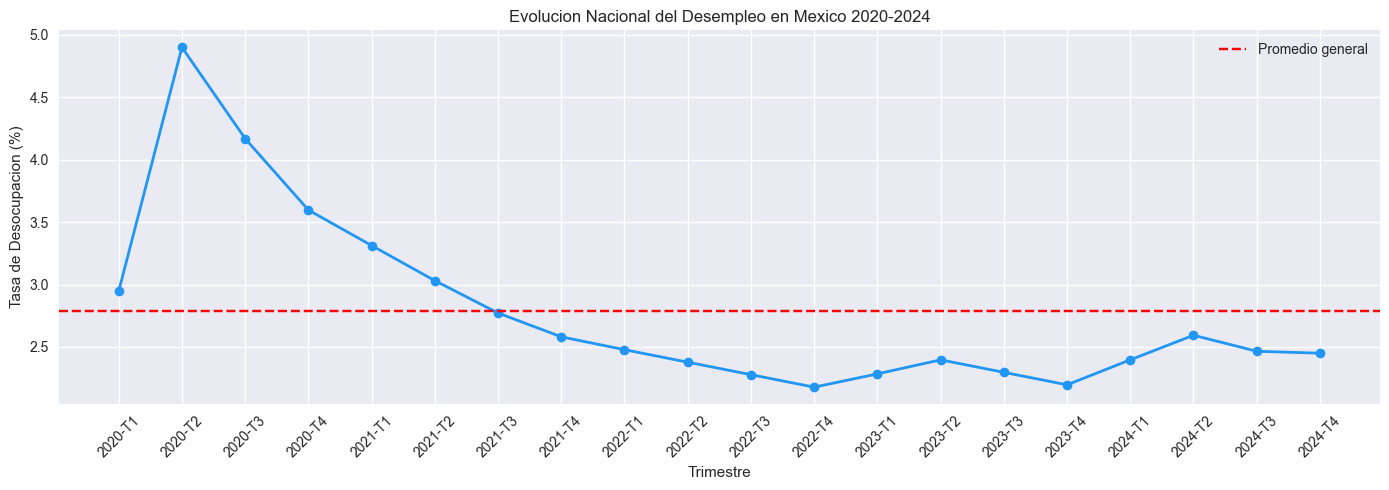

In [7]:
# Promedio nacional por trimestre
evolucion = registros.groupby('periodo_label')['tasa_desocupacion'].mean().reset_index()

# Ordenar cronológicamente
evolucion = evolucion.sort_values('periodo_label')

# Gráfico
plt.figure(figsize=(14, 5))
plt.plot(evolucion['periodo_label'], evolucion['tasa_desocupacion'],
         marker='o', color='#2196F3', linewidth=2)
plt.axhline(y=evolucion['tasa_desocupacion'].mean(), color='red',
            linestyle='--', label='Promedio general')
plt.title('Evolucion Nacional del Desempleo en Mexico 2020-2024')
plt.xlabel('Trimestre')
plt.ylabel('Tasa de Desocupacion (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Visualización 2: Top 10 estados con mayor desempleo promedio 2020-2024.

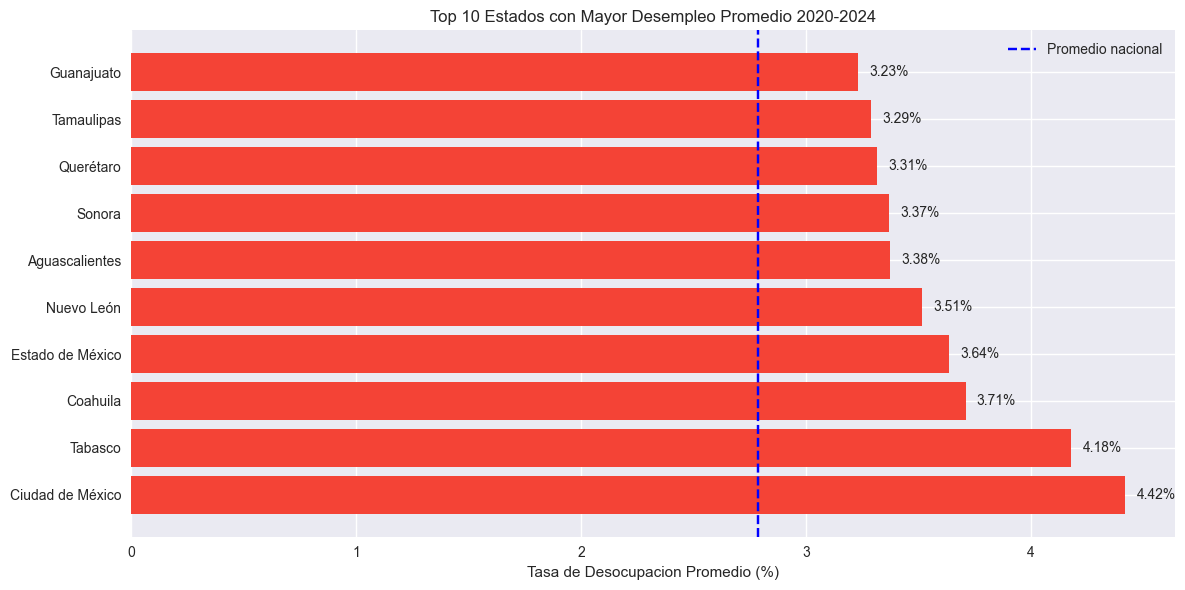

In [8]:
# Promedio de desocupacion por estado
top_estados = registros.groupby('entidad')['tasa_desocupacion'].mean().reset_index()
top_estados = top_estados.sort_values('tasa_desocupacion', ascending=False).head(10)

# Grafico
plt.figure(figsize=(12, 6))
bars = plt.barh(top_estados['entidad'], top_estados['tasa_desocupacion'],
                color='#F44336')
plt.axvline(x=registros['tasa_desocupacion'].mean(), color='blue',
            linestyle='--', label=f'Promedio nacional')
plt.title('Top 10 Estados con Mayor Desempleo Promedio 2020-2024')
plt.xlabel('Tasa de Desocupacion Promedio (%)')
plt.legend()

for bar, val in zip(bars, top_estados['tasa_desocupacion']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center')

plt.tight_layout()
plt.show()

### Visualizacion 3: Informalidad laboral por region 2024.

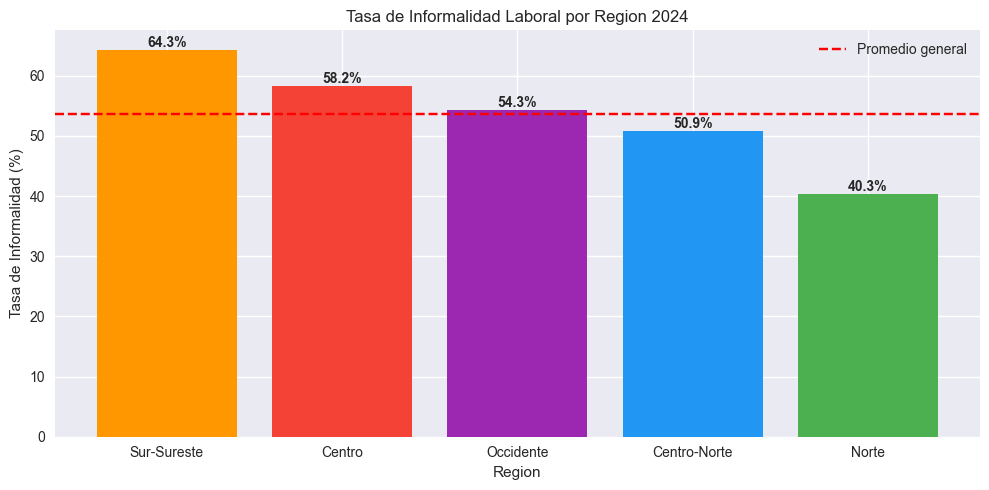

In [9]:
# Promedio de informalidad por region
informalidad = estados.groupby('region')['informalidad_2024'].mean().reset_index()
informalidad = informalidad.sort_values('informalidad_2024', ascending=False)

# Grafico
plt.figure(figsize=(10, 5))
bars = plt.bar(informalidad['region'], informalidad['informalidad_2024'],
               color=['#FF9800', '#F44336', '#9C27B0', '#2196F3', '#4CAF50'])
plt.axhline(y=informalidad['informalidad_2024'].mean(), color='red',
            linestyle='--', label='Promedio general')
plt.title('Tasa de Informalidad Laboral por Region 2024')
plt.xlabel('Region')
plt.ylabel('Tasa de Informalidad (%)')
plt.legend()

for bar, val in zip(bars, informalidad['informalidad_2024']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Visualizacion 4: Mapa de calor del desempleo por estado y año.

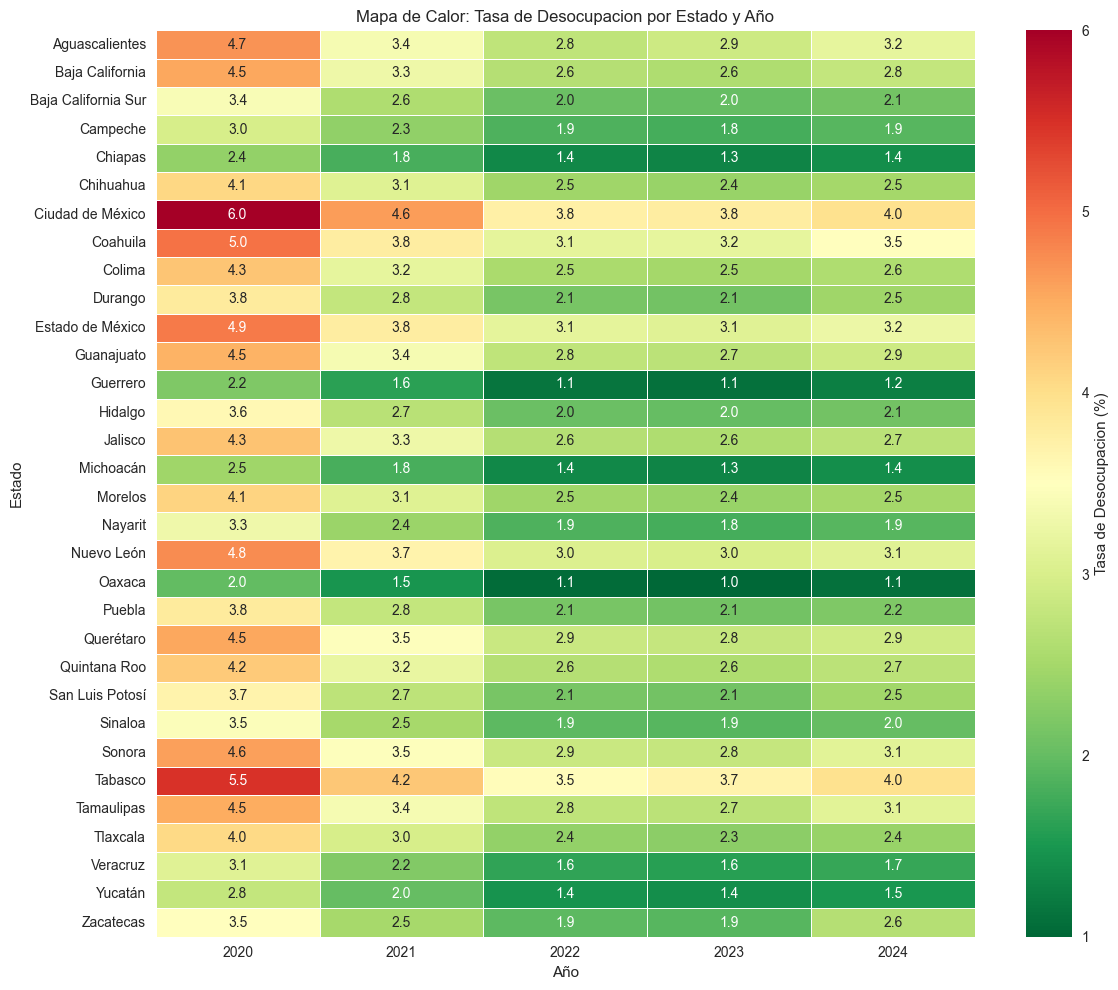

In [10]:
# Promedio anual por estado
registros['anio'] = registros['anio'].astype(str)
pivot = registros.pivot_table(
    index='entidad',
    columns='anio',
    values='tasa_desocupacion',
    aggfunc='mean'
).round(2)

# Grafico
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Tasa de Desocupacion (%)'})
plt.title('Mapa de Calor: Tasa de Desocupacion por Estado y Año')
plt.xlabel('Año')
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

### Visualizacion 5: Comparativa informalidad vs desempleo por estado.

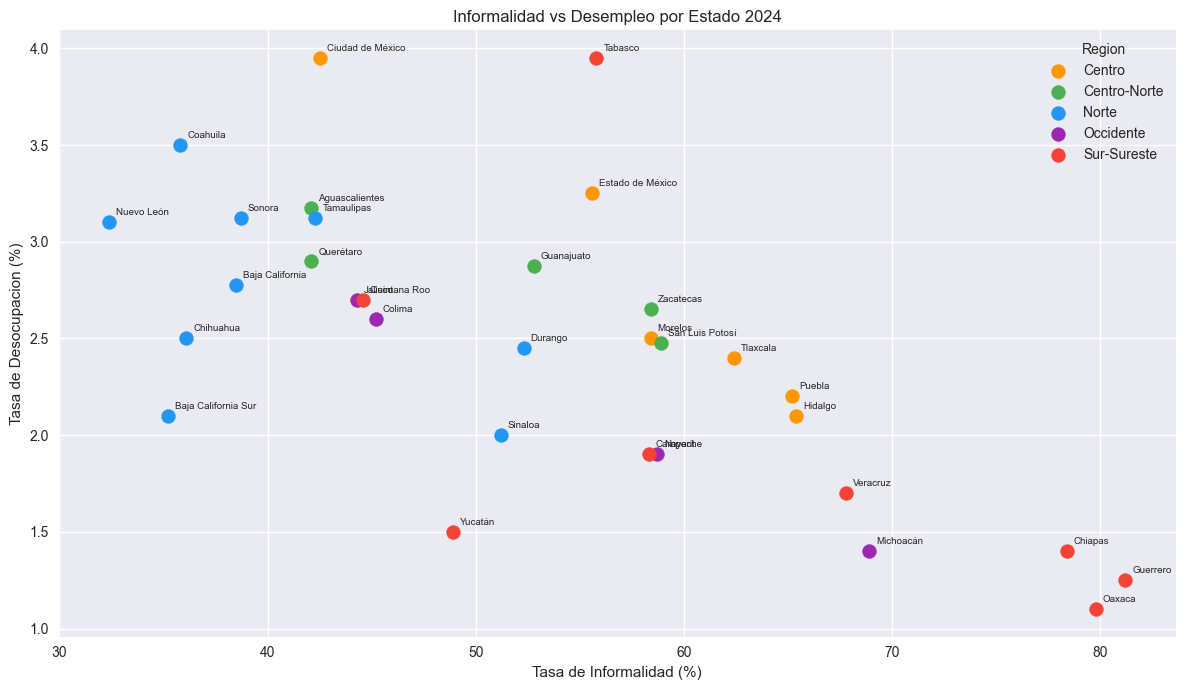

In [11]:
# Promedio de desocupacion 2024 por estado
desempleo_2024 = registros[registros['anio'] == '2024'].groupby('entidad')['tasa_desocupacion'].mean().reset_index()
desempleo_2024.columns = ['entidad', 'desempleo_2024']

# Unir con informalidad
scatter_data = estados[['entidad', 'informalidad_2024', 'region']].merge(
    desempleo_2024, on='entidad'
)

# Colores por region
colores = {
    'Norte': '#2196F3',
    'Centro-Norte': '#4CAF50',
    'Centro': '#FF9800',
    'Occidente': '#9C27B0',
    'Sur-Sureste': '#F44336'
}

# Grafico
plt.figure(figsize=(12, 7))
for region, grupo in scatter_data.groupby('region'):
    plt.scatter(grupo['informalidad_2024'], grupo['desempleo_2024'],
                label=region, color=colores[region], s=100, zorder=5)
    for _, row in grupo.iterrows():
        plt.annotate(row['entidad'],
                     (row['informalidad_2024'], row['desempleo_2024']),
                     textcoords='offset points', xytext=(5, 5), fontsize=7)

plt.title('Informalidad vs Desempleo por Estado 2024')
plt.xlabel('Tasa de Informalidad (%)')
plt.ylabel('Tasa de Desocupacion (%)')
plt.legend(title='Region')
plt.tight_layout()
plt.show()

## Etapa 3: Conclusiones.

### Hallazgos principales.

1. **Impacto COVID-19:** El segundo trimestre de 2020 registró el pico 
   máximo de desempleo nacional (~4.9%), con recuperación progresiva 
   hasta estabilizarse en ~2.5% en 2022-2024.

2. **Estados críticos:** Ciudad de México (4.42%) y Tabasco (4.18%) 
   lideran el desempleo promedio 2020-2024, ambos por encima del 
   promedio nacional de 2.79%.

3. **Brecha regional de informalidad:** El Sur-Sureste tiene una tasa 
   de informalidad del 64.3%, casi 24 puntos porcentuales por encima 
   del Norte (40.3%), lo que refleja una desigualdad estructural 
   en el mercado laboral mexicano.

4. **Paradoja sur del país:** Estados como Oaxaca y Guerrero tienen 
   bajo desempleo oficial pero altísima informalidad, lo que indica 
   que la gente trabaja en condiciones precarias sin acceso a 
   seguridad social.

5. **Recuperación generalizada:** Para 2022-2024 todos los estados 
   lograron reducir su tasa de desempleo por debajo de los niveles 
   prepandemia, mostrando resiliencia del mercado laboral mexicano.

### Recomendaciones.

- Focalizar politicas de formalizacion laboral en la region Sur-Sureste
- Atender de forma prioritaria a Tabasco y Ciudad de Mexico 
  con programas de empleo formal
- Monitorear la evolucion del mercado laboral post-2024 dado que 
  los niveles historicamente bajos podrian ser vulnerables ante 
  nuevas crisis economicas

### Fuente.
INEGI - Encuesta Nacional de Ocupacion y Empleo (ENOE)
https://www.inegi.org.mx/programas/enoe/15ymas/